A partir del dataset que se propone, zoo.

+info: https://www.kaggle.com/uciml/zoo-animal-classification?select=zoo.csv

Responde a las preguntas presentadas

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error


# IMPORTAR CSV DESDE GOOGLE DRIVE

In [ ]:
#https://drive.google.com/file/d/1qyi3ZJrkhWak7eLtps4_hmRm0B4OID6V/view?usp=sharing

file_id = '1qyi3ZJrkhWak7eLtps4_hmRm0B4OID6V'
url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url, sep=',')

**PREGUNTAS**:

#1. Inspeccionar dataset

In [ ]:
df.shape

(101, 18)

In [ ]:
df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


#2. Estadisticas

In [ ]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


#3. Valores Nan (missing values)

In [ ]:
df.isnull().sum()

,0
animal_name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


#4. Varianzas

In [ ]:
variances = df.select_dtypes(include=np.number).var().sort_values(ascending=False)

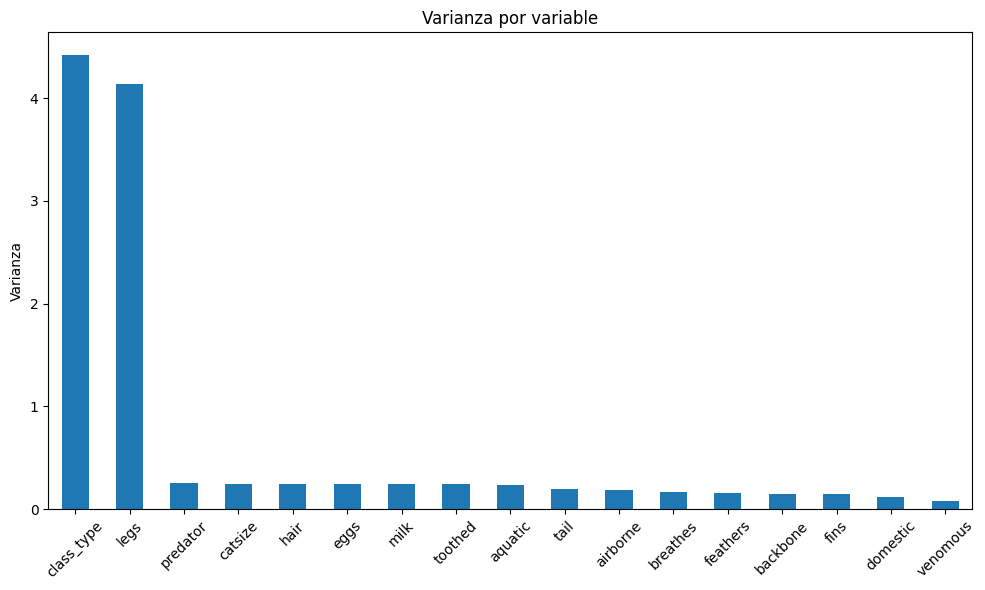

In [ ]:
plt.figure(figsize=(10,6))
variances.plot(kind='bar')
plt.title('Varianza por variable')
plt.ylabel('Varianza')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#5. Correlacion Pearson ¿Cuales son las variables que más correlacionadas están con el target?

In [ ]:
# Separar features y target
target = 'class_type'
X = df.drop(columns=[target])
y = df[target]

In [ ]:
X_numeric = X.select_dtypes(include=['number'])

In [ ]:
correlations = X_numeric.corrwith(y).abs().sort_values(ascending=False)
print(correlations)

backbone    0.828845
milk        0.723683
eggs        0.661825
tail        0.631830
hair        0.562384
catsize     0.521030
breathes    0.519308
toothed     0.471527
aquatic     0.326639
venomous    0.321476
feathers    0.197520
domestic    0.181043
legs        0.131693
fins        0.099430
predator    0.061179
airborne    0.022677
dtype: float64


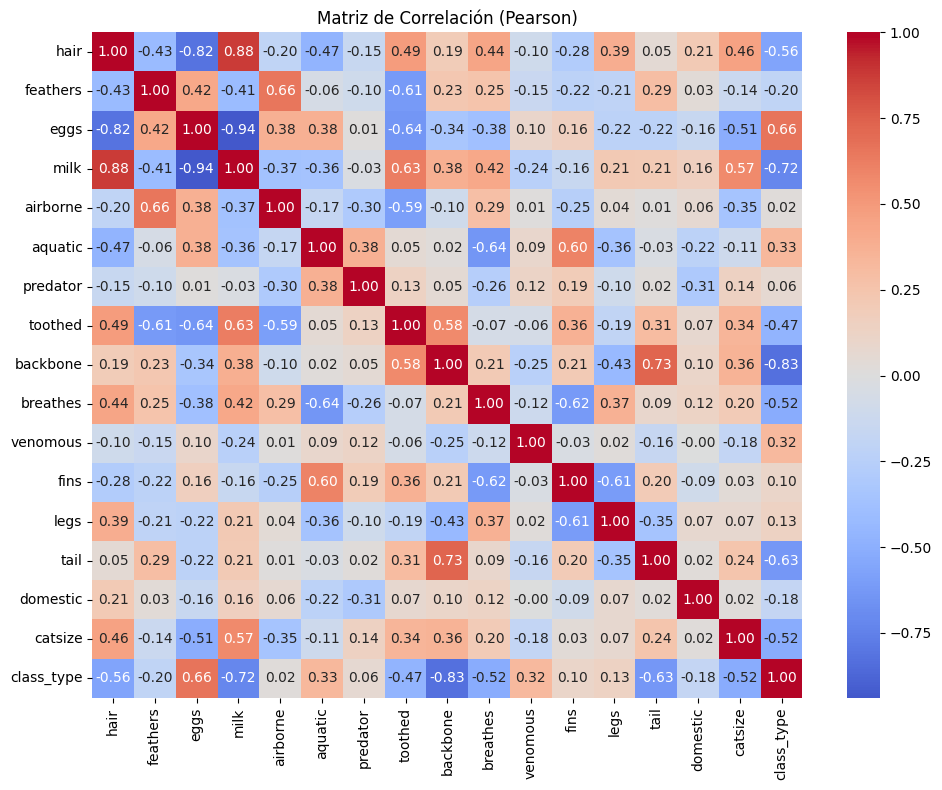

In [ ]:
df_numeric = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación (Pearson)')
plt.tight_layout()
plt.show()

#6. ¿Qué variable la correlación máxima y cual es su valor?

In [ ]:
max_corr_var = correlations.index[0]
print(max_corr_var)

backbone


In [ ]:
max_corr_val = correlations.iloc[0]
print(max_corr_val)

0.8288452641993184


#7. ¿Se observa alguna diferencia al aplicar Spearman en lugar de Pearson? ¿ A qué es debido?

In [ ]:
spearman_corr = X_numeric.corrwith(y, method='spearman').abs().sort_values(ascending=False)

In [ ]:
# Spearman
print(spearman_corr.head())

milk        0.886024
eggs        0.819282
hair        0.732588
backbone    0.690483
catsize     0.578225
dtype: float64


In [ ]:
# Pearson
print(correlations.head())

backbone    0.828845
milk        0.723683
eggs        0.661825
tail        0.631830
hair        0.562384
dtype: float64


In [ ]:
# Diferencias
diff = (spearman_corr - correlations).abs().sort_values(ascending=False)
print("Diferencias más grandes (Spearman - Pearson):")
print(diff.head())

#¿A qué se debe?:
  # 1. Pearson mide relación lineal.
  # 2. Spearman mide relación monotónica (no necesariamente lineal).
# Si hay relaciones no lineales pero monotónicas, Spearman dará mayor valor.

# No Lineal = Significa que si se grafican los datos,
# los puntos NO forman una línea recta perfecta
# Monotónica = Se mueven en la mísma dirección (monotónica creciente) o
# en direcciones opuestas (monotónica decreciente)

Diferencias más grandes (Spearman - Pearson):
feathers    0.188644
hair        0.170204
milk        0.162341
eggs        0.157456
backbone    0.138362
dtype: float64


#8. Aplicando backward elimination, ¿Con qué variables nos quedamos?

In [ ]:
def backward_elimination(X, y, significance_level=0.05):
    features = list(X.columns)
    while len(features) > 0:
        X_with_const = pd.concat([pd.Series(1, index=X.index, name='const'), X[features]], axis=1)
        # Usar OLS (regresión lineal)
        model = sm.OLS(y, X_with_const).fit()
        pvalues = model.pvalues.iloc[1:]  # Excluir const
        max_pvalue = pvalues.max()
        if max_pvalue > significance_level:
            feature_to_remove = pvalues.idxmax()
            features.remove(feature_to_remove)
            print(f"Eliminada: {feature_to_remove} (p-value: {max_pvalue:.4f})")
        else:
            break
    return features

In [ ]:
# Estandarizar
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)

selected_features_backward = backward_elimination(X_scaled, y)
print(f"\nVariables finales con Backward Elimination: {selected_features_backward}")

Eliminada: venomous (p-value: 0.9696)
Eliminada: domestic (p-value: 0.9567)
Eliminada: catsize (p-value: 0.3956)
Eliminada: breathes (p-value: 0.3036)
Eliminada: legs (p-value: 0.3784)
Eliminada: predator (p-value: 0.3207)
Eliminada: hair (p-value: 0.1985)
Eliminada: tail (p-value: 0.1458)
Eliminada: eggs (p-value: 0.0557)

Variables finales con Backward Elimination: ['feathers', 'milk', 'airborne', 'aquatic', 'toothed', 'backbone', 'fins']


#9. ¿Cuál es el número óptimo de variables a tener en cuenta usando el método de RFE, cuales son?

In [ ]:
# Usamos regresión lineal como estimador
estimator = LinearRegression()
rfe_scores = []

In [ ]:
for n in range(1, len(X_numeric.columns) + 1):
    rfe = RFE(estimator, n_features_to_select=n)
    rfe.fit(X_scaled, y)
    rfe_scores.append(rfe.score(X_scaled, y))

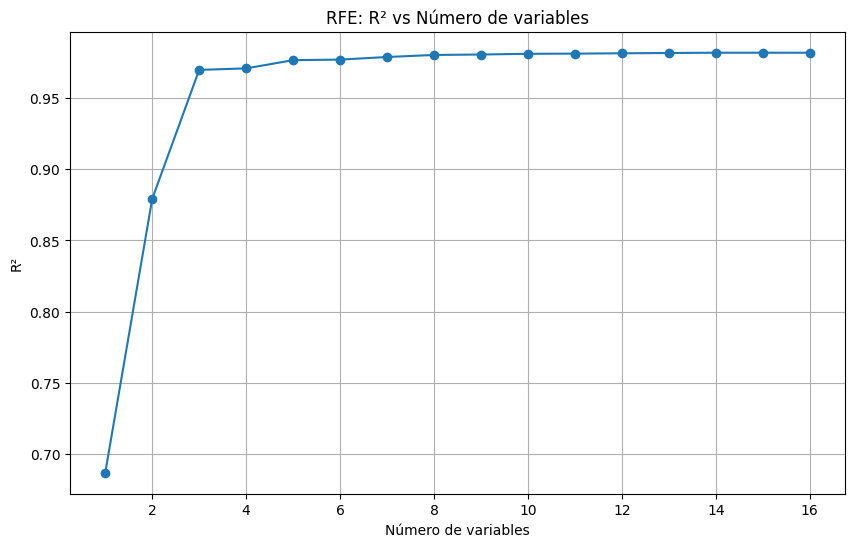

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(rfe_scores)+1), rfe_scores, marker='o')
plt.xlabel('Número de variables')
plt.ylabel('R²')
plt.title('RFE: R² vs Número de variables')
plt.grid(True)
plt.show()

In [ ]:
optimal_n = np.argmax(rfe_scores) + 1
rfe_optimal = RFE(estimator, n_features_to_select=optimal_n)
rfe_optimal.fit(X_scaled, y)
selected_rfe = X_numeric.columns[rfe_optimal.support_].tolist()

print(f"Número óptimo de variables (RFE): {optimal_n}")
print(f"Variables seleccionadas: {selected_rfe}")

Número óptimo de variables (RFE): RFE(estimator=LinearRegression(), n_features_to_select=np.int64(16))
Variables seleccionadas: ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']


#10. ¿Cuantas variables elimina RIDGE y cúales son?¿Y LASSO?

In [ ]:
# Estandarización necesaria
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_coef = pd.Series(ridge.coef_, index=X_numeric.columns)
ridge_zero = ridge_coef[abs(ridge_coef) < 1e-10]

In [ ]:
print(f"Ridge eliminó {len(ridge_zero)} variables (coef ≈ 0):")
print(ridge_zero.index.tolist() if len(ridge_zero) > 0 else "Ninguna")

Ridge eliminó 0 variables (coef ≈ 0):
Ninguna


In [ ]:
# Lasso
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train, y_train)
lasso_coef = pd.Series(lasso.coef_, index=X_numeric.columns)
lasso_zero = lasso_coef[lasso_coef == 0]

In [ ]:
print(f"\nLasso eliminó {len(lasso_zero)} variables (coef = 0):")
print(lasso_zero.index.tolist())


Lasso eliminó 2 variables (coef = 0):
['eggs', 'domestic']


#11. ¿Usando 2 componentes, que peso tiene la variable "domestic" en la componente 1?

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Peso de 'domestic' en PC1

domestic_idx = X_numeric.columns.get_loc('domestic')
pc1_weight_domestic = pca.components_[0, domestic_idx]
print(f"Peso de 'domestic' en Componente 1: {pc1_weight_domestic:.4f}")

Peso de 'domestic' en Componente 1: 0.0968


#12. ¿Cuantos coeficientes se obtienen en LDA y cuales son sus valores? Razona la respuesta

In [ ]:
# LDA busca maximizar la separación entre clases.
# Se obtienen {len(lda_coef)} coeficientes (uno por variable).
# Representan la contribución de cada variable a la dirección de máxima discriminación.

In [ ]:
# LDA requiere clases (clasificación). Si es regresión, no aplica.
# Asumimos que es clasificación (ajusta si es regresión)

In [ ]:
try:
    lda = LDA(n_components=1)
    lda.fit(X_scaled, y.astype(int))  # Asegúrate de que y sea categórica
    lda_coef = pd.Series(lda.coef_[0], index=X_numeric.columns)
    print("Coeficientes LDA (para separación entre clases):")
    display(lda_coef.sort_values(ascending=False))

except Exception as e:
    print("LDA falló. Asegúrate de que el target sea categórico (clasificación). Error:", e)

Coeficientes LDA (para separación entre clases):


,0
milk,4.520136e+31
feathers,3.619968e+31
backbone,2.760572e+31
hair,2.177115e+01
predator,1.045863e+01
tail,8.002619e+00
domestic,5.004302e+00
aquatic,2.171029e+00
catsize,1.741055e+00
airborne,1.482019e+00
